<a href="https://colab.research.google.com/github/rll/deepul/blob/master/homeworks/hw1/hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment2
In each homework problem, you will implement generative models and run it on various datasets. Oftentime you will run it on two datasets (dataset 1 and dataset 2). In these cases, the expected outputs for dataset 1 are already provided to help as a sanity check.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

**After you complete the assignment, download all of the images outputted in the results/ folder and upload them as a zip file with Final Test Loss.**

There is a lot of freedom in this homework to write ,and design your own models. Hyperparameters are given as a guide to show what worked for us, but feel free to explore and use what you find is best!

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

from hw1_helper import (
    # Q1
    visualize_q1_data,
    q1_sample_data_1,
    q1_sample_data_2,
    q1_save_results,
    # Q2
    q2a_save_results,
    visualize_q2a_data,
    q2b_save_results
)

# Question 1: 1D Data

In this question, we will train simple generative models on discrete 1D data.

Execute the cell below to visualize our datasets

Dataset 1


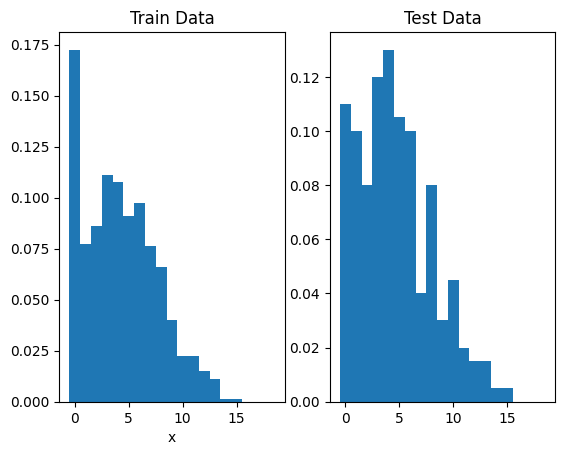

Dataset 2


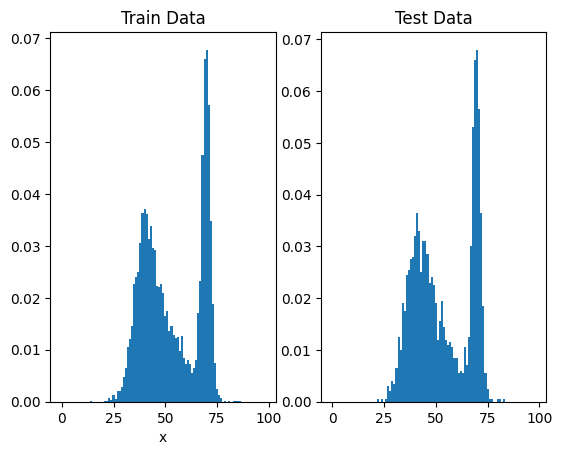

In [3]:
visualize_q1_data(dset_type=1)
visualize_q1_data(dset_type=2)

## Fitting a Histogram

Let $\theta = (\theta_0, \dots, \theta_{d-1}) \in \mathbb{R}^{d}$ and define the model $p_\theta(x) = \frac{e^{\theta_x}}{\sum_{x'}e^{\theta_{x'}}}$

Fit $p_\theta$ with maximum likelihood via stochastic gradient descent on the training set, using $\theta$ initialized to zero. Use your favorite version of stochastic gradient descent, and optimize your hyperparameters on a validation set of your choice.

**You will provide these deliverables**


1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves. 
2.   Report the final test set performance of your final model
3. Plot the model probabilities in a bar graph with $\{0,\dots,d-1\}$ on the x-axis and a real number in $[0,1]$ on the y-axis.




Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.


**You may fill in the TODOs in the provided code, but you are also free to implement q1_a in a completely different way if you prefer. The TODOs are intended only as a guide for a naive implementation. Please keep the return format of the q1_a function unchanged.**

In [4]:
def q1_a(train_data, test_data, d, dset_id):
  """
  train_data: An (n_train,) numpy array of integers in {0, ..., d-1}
  test_data: An (n_test,) numpy array of integers in {0, .., d-1}
  d: The number of possible discrete values for random variable x
  dset_id: An identifying number of which dataset is given (1 or 2). Most likely
             used to set different hyperparameters for different datasets

  Returns
  - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
  - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
  - a numpy array of size (d,) of model probabilities
  """
  
  # hyperparameters
  n_epochs = 20
  batch_size = 128
  lr = 0.1

  # parameter initialization
  theta = torch.zeros(d, requires_grad=True)
  optimizer = torch.optim.Adam([theta], lr= lr)

  # numpy array to tensor
  train_tensor = torch.from_numpy (train_data).long()
  test_tensor = torch.from_numpy(test_data).long()

  train_losses = [] # for every minibatch
  test_losses = [] # for every epoch



  ##############################################Fill in##############################################
  def compute_loss(data_tensor):
    # 1) Convert theta into log-probabilities over d categories.
    log_probs = F.log_softmax(theta, dim=0)
    # 2) Return the average negative log-likelihood of data_tensor.
    loss = -log_probs[data_tensor].mean()
    return loss
  ###################################################################################################


  with torch.no_grad():
    test_losses.append(compute_loss(test_tensor))
  
  # training loop
  n_train = len(train_tensor)
  for epoch in range(n_epochs):
    for i in range(0, n_train, batch_size):
      batch = train_tensor[i: i+batch_size]

      optimizer.zero_grad()
      loss = compute_loss(batch)
      loss.backward()
      optimizer.step()
      train_losses.append(loss.item())
    
    with torch.no_grad():
      test_losses.append(compute_loss(test_tensor).item())



  ##############################################Fill in##############################################
  with torch.no_grad():
    # Convert theta into a probability distribution of shape (d,).
    distribution = F.softmax(theta, dim=0).numpy()
  ###################################################################################################

  

  return np.array(train_losses), np.array(test_losses), distribution

### Results

Once you've implemented `q1_a`, execute the cells below to visualize and save your results



Final Test Loss: 2.5416


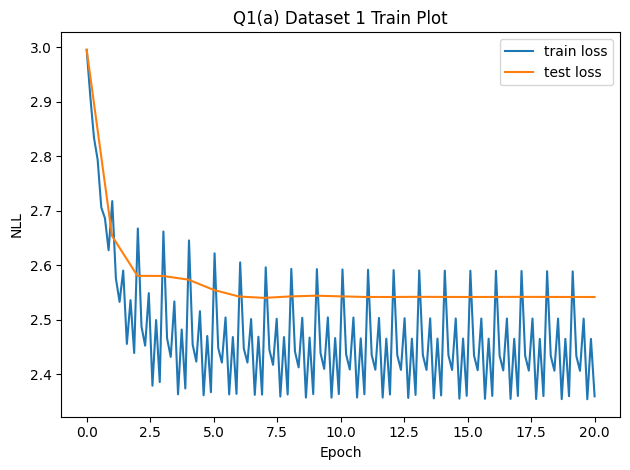

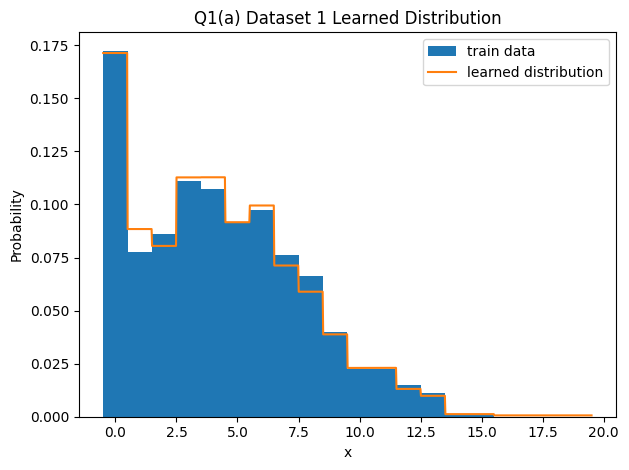

In [5]:
q1_save_results(1, 'a', q1_a)

Final Test Loss: 3.6678


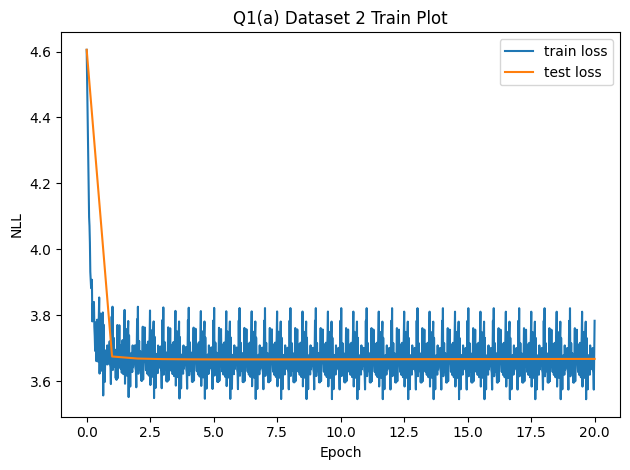

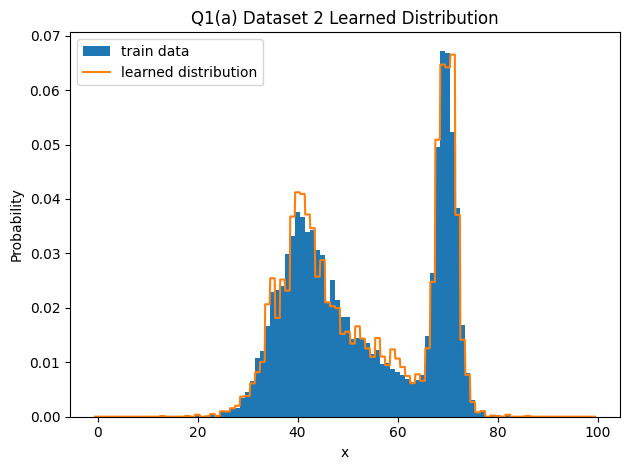

In [6]:
q1_save_results(2, 'a', q1_a)

# Question 2 (Simple) PixelRNN

Now, you will train more powerful PixelRNN models on the shapes dataset and MNIST. In addition, we will extend to modeling colored datasets.

Run the cell below to visualize the two datasets binary datasets

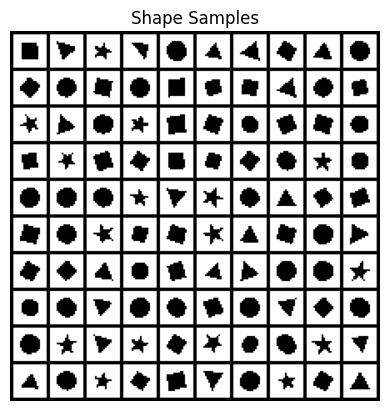

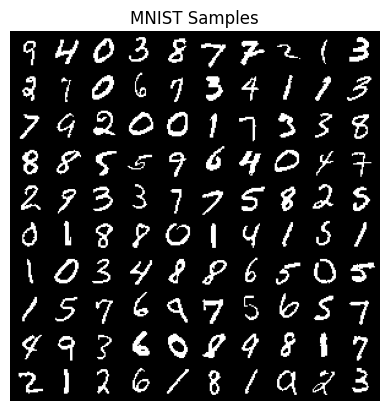

In [7]:
visualize_q2a_data(1)
visualize_q2a_data(2)

## Simple PixelRNN on Shapes and MNIST
In this part, you will implement a simple PixelRNN architecture for modeling binarized MNIST and shape images.

**Each image should first be flattened into a one-dimensional sequence, and the model will be trained to predict the next pixel autoregressively.**

While the original PixelRNN uses a more sophisticated architecture, the objective of this assignment is to work with a simplified version.

We recommend the following network design: 3 Layers for gru and 1 layer for fc 

And the following hyperparameters:
* Batch size 128
* Learning rate $10^{-3}$
* 20 epochs
* Adam Optimizer

Your model should output logits, after which you could apply a sigmoid over 1 logit, or a softmax over two logits (either is fine).

Training on the shapes dataset should be quick (2 minutes in my setting), and MNIST should take around 20 minutes

Checkout the Paper for more details: https://arxiv.org/abs/1601.06759

**You will provide these deliverables**

1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves. 
2.   Report the final test set performance of your final model
3. 100 samples from the final trained model



Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.


**You may fill in the TODOs in the provided code, but you are also free to implement q2_a and PixelRNN in a completely different way if you prefer. The TODOs are intended only as a guide for a naive implementation. Just please keep the return format of the q2_a function unchanged.**

In [8]:
# model definition
class PixelRNN(nn.Module):
  def __init__(self, num_layers=3, hidden_dim=256):
    super().__init__()
    
    # pixel value (0 or 1) -> embedding vector
    self.embed = nn.Embedding(2, hidden_dim)

    # GRU for autoregressive sequence modeling
    self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    # output layer: hidden state -> logit for Bernoulli distribution
    self.fc = nn.Linear(hidden_dim, 1)
  
  
  ##############################################Fill in##############################################
  def forward(self, x):
    # 1) Convert input tokens into embeddings
    emb = self.embed(x)
    # 2) Pass them through the GRU
    out, _ = self.gru(emb)
    # 3) Map each hidden state to a scalar logit
    return self.fc(out)
  ###################################################################################################


def q2_a(train_data, test_data, image_shape, dset_id):
  """
  train_data: A (n_train, H, W, 1) uint8 numpy array of binary images with values in {0, 1}
  test_data: A (n_test, H, W, 1) uint8 numpy array of binary images with values in {0, 1}
  image_shape: (H, W), height and width of the image
  dset_id: An identifying number of which dataset is given (1 or 2). Most likely
           used to set different hyperparameters for different datasets

  Returns
  - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
  - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
  - a numpy array of size (100, H, W, 1) of samples with values in {0, 1}
  """

  # hyperparams
  n_epochs   = 20
  batch_size = 128
  lr         = 1e-3
  hidden_dim = 256
  num_layers = 3
  H, W = image_shape
  T = H * W
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  ##############################################Fill in##############################################
  # data preprocess
  def preprocess(data):
    # Convert data from shape (N, H, W, 1) to shape (N, T),
    # where T = H * W, and cast to LongTensor.
    x = torch.from_numpy(data).view(data.shape[0], -1).long()
    return x
  ###################################################################################################
  
  train_t = preprocess(train_data)
  test_t = preprocess(test_data)

  train_loader = DataLoader(
    TensorDataset(train_t),
    batch_size = batch_size,
    shuffle=True,
    pin_memory=True
  )

  test_loader = DataLoader(
    TensorDataset(test_t),
    batch_size = batch_size,
    shuffle=True,
    pin_memory=True
  )

  # model definition
  model = PixelRNN(num_layers, hidden_dim).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)



  ##############################################Fill in##############################################
  # loss function (Teacher Forcing)
  def compute_loss(x):
    x = x.to(device, non_blocking=True)

    # Create an SOS(Start of Sequence) column of zeros with shape (B, 1)
    sos = torch.zeros(x.size(0), 1, dtype=torch.long, device=device)
    # inp = [SOS, x_0, x_1, ..., x_{T-2}]
    inp = torch.cat([sos, x[:, :-1]], dim=1)

    # Run the model and remove the last singleton dimension.
    logits = model(inp).squeeze(-1)

    # Compute the binary cross-entropy loss between predicted logits
    return F.binary_cross_entropy_with_logits(logits, x.float())
  ###################################################################################################

  def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
      for (batch,) in loader:
        loss = compute_loss(batch)
        bs = batch.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss/total_count

  train_losses, test_losses = [], []
  test_losses.append(evaluate(test_loader))

  for epoch in range(n_epochs):
    model.train()

    for (batch,) in train_loader:
      optimizer.zero_grad()
      loss = compute_loss(batch)
      loss.backward()
      optimizer.step()

      train_losses.append(loss.item())

    test_loss = evaluate(test_loader)
    test_losses.append(test_loss)

    print(f"Epoch: {epoch+1}/{n_epochs} | test loss: {test_loss:.4f}")

  ##############################################Fill in##############################################
  model.eval()
  n_samples = 100
  with torch.no_grad():
    samples = torch.zeros(n_samples, T, dtype=torch.long, device=device)
    for t in range(T):
      # Build the current autoregressive prefix input:
      sos = torch.zeros(n_samples, 1, dtype=torch.long, device=device)
      inp = torch.cat([sos, samples[:, :t]], dim=1)

      # Predict the logit for the current position t
      logit = model(inp)[:, t, 0]

      # Convert the logit to a Bernoulli probability
      prob = torch.sigmoid(logit)

      # Sample 0/1 values from the Bernoulli distribution and store them at position t.
      samples[:, t] = torch.bernoulli(prob).long()
  ###################################################################################################
  
  samples = samples.cpu().numpy()
  samples = samples.reshape(n_samples, H, W, 1).astype(np.uint8)

  # return np.array(train_losses),  np.array(test_losses), samples
  return np.array(train_losses),  np.array(test_losses), samples, model

### Results

Once you've implemented `q2_a`, execute the cells below to visualize and save your results



Epoch: 1/20 | test loss: 0.1148
Epoch: 2/20 | test loss: 0.0990
Epoch: 3/20 | test loss: 0.1049
Epoch: 4/20 | test loss: 0.0939
Epoch: 5/20 | test loss: 0.0841
Epoch: 6/20 | test loss: 0.0897
Epoch: 7/20 | test loss: 0.0747
Epoch: 8/20 | test loss: 0.0725
Epoch: 9/20 | test loss: 0.0661
Epoch: 10/20 | test loss: 0.0626
Epoch: 11/20 | test loss: 0.0631
Epoch: 12/20 | test loss: 0.0599
Epoch: 13/20 | test loss: 0.0578
Epoch: 14/20 | test loss: 0.0585
Epoch: 15/20 | test loss: 0.0619
Epoch: 16/20 | test loss: 0.0538
Epoch: 17/20 | test loss: 0.0528
Epoch: 18/20 | test loss: 0.0510
Epoch: 19/20 | test loss: 0.0506
Epoch: 20/20 | test loss: 0.0492
Final Test Loss: 0.0492


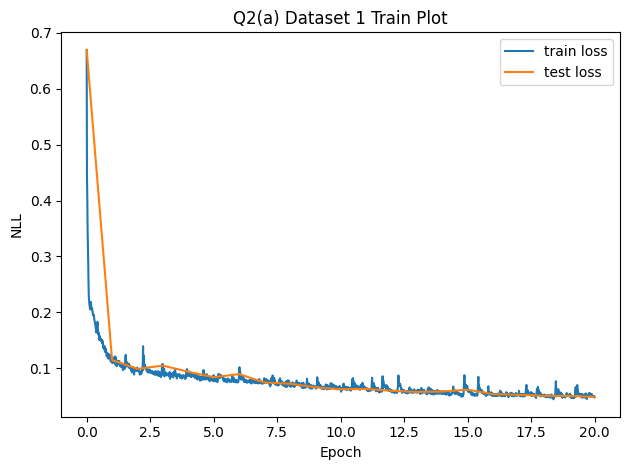

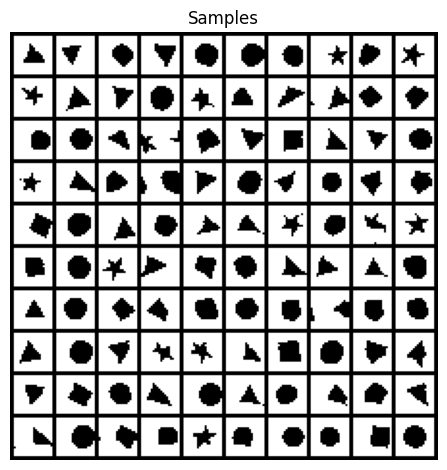

In [9]:
# This model will also be used for inference
model_shape = q2a_save_results(1, q2_a)

Epoch: 1/20 | test loss: 0.0965
Epoch: 2/20 | test loss: 0.0878
Epoch: 3/20 | test loss: 0.0863
Epoch: 4/20 | test loss: 0.0834
Epoch: 5/20 | test loss: 0.0829
Epoch: 6/20 | test loss: 0.0811
Epoch: 7/20 | test loss: 0.0812
Epoch: 8/20 | test loss: 0.0795
Epoch: 9/20 | test loss: 0.0781
Epoch: 10/20 | test loss: 0.0778
Epoch: 11/20 | test loss: 0.0772
Epoch: 12/20 | test loss: 0.0801
Epoch: 13/20 | test loss: 0.0773
Epoch: 14/20 | test loss: 0.0772
Epoch: 15/20 | test loss: 0.0776
Epoch: 16/20 | test loss: 0.0794
Epoch: 17/20 | test loss: 0.0758
Epoch: 18/20 | test loss: 0.0753
Epoch: 19/20 | test loss: 0.0758
Epoch: 20/20 | test loss: 0.0768
Final Test Loss: 0.0768


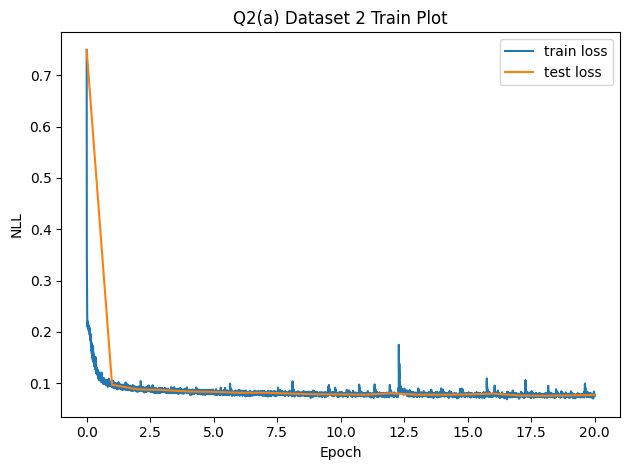

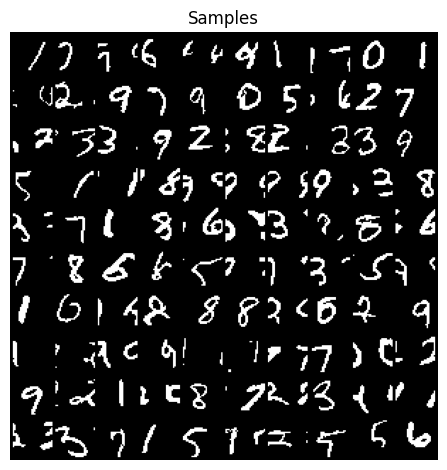

In [10]:
# This model will also be used for inference.
model_mnist = q2a_save_results(2, q2_a)

### Question 2 (b) - Inference (Likelihood Calculation)

Let us examine whether the trained PixelRNN model assigns a higher probability (equivalently, lower Negative Log-Likelihood, NLL) to genuine images from the true data distribution.
To do this, we intentionally add bit-flip noise to the images and compare the model’s average NLL on the original images versus the corrupted images.

> **Note**: When evaluating autoregressive generative models such as PixelRNN, the total probability of an individual image is typically extremely close to zero because it is computed as the product of probabilities over a large number of pixels. As a result, direct comparison of raw probability values is not practical.
Therefore, we use the **Average Negative Log-Likelihood (Average NLL)**, obtained by normalizing the NLL by the number of pixels, as the evaluation metric.
A lower NLL indicates that the model assigns a higher likelihood to the image under the learned data distribution.

**You will provide the following deliverables:**

1. An NLL comparison bar plot
2. A grid of original vs. perturbed images

In [11]:
import torch.nn.functional as F

def q2_b(model, test_data, device, noise_ratios=[0.1, 0.3, 0.5], N=10):
    """
    Args:
        model        : trained PixelRNN model
        test_data    : (n_test, H, W, 1) uint8 numpy array
        device       : torch.device
        noise_ratios : list of bit-flip ratios to apply (e.g. [0.1, 0.3, 0.5])
        N            : number of test samples to evaluate

    Returns:
        true_nll              : (N,) numpy array — avg NLL per original image
        perturbed_nlls        : dict {float: (N,) numpy array} — avg NLL per noise ratio
        test_samples          : (N, H, W, 1) numpy array — original samples used
        perturbed_samples_dict: dict {float: torch.Tensor (N, H, W, 1)} — perturbed images
    """
    
    ##############################################Fill in##############################################
    def compute_avg_nll(x):
        model.eval()
        with torch.no_grad():
            if not isinstance(x, torch.Tensor):
                x = torch.from_numpy(x.copy())
            x = x.to(device).squeeze(-1).long().reshape(x.size(0), -1)  # (N, T)

            # prepend SOS token and run the model forward pass
            sos = torch.zeros(x.size(0), 1, dtype=torch.long, device=device)
            inp = torch.cat([sos, x[:, :-1]], dim=1)

            # Run the model and remove the last singleton dimension.
            logits = model(inp).squeeze(-1) # shape: (N, T)

            # compute per-pixel NLL using BCE loss,
            # reduction='none'을 통해 픽셀별 Loss를 구합니다.
            nll =  F.binary_cross_entropy_with_logits(logits, x.float(), reduction='none')
            # return the **per-image** average
            return nll.mean(dim=1).cpu().numpy()
    ###################################################################################################
    
    ##############################################Fill in##############################################
    def apply_bit_flip_perturbation(x, noise_ratio):
        if not isinstance(x, torch.Tensor):
            x = torch.from_numpy(x.copy())

        # create a boolean mask where each pixel is True with probability noise_ratio,
        mask = torch.rand(x.shape, device=x.device) < noise_ratio
        
        # flip those pixels (0->1, 1->0) using torch.where
        return torch.where(mask, 1 - x, x)
    ###################################################################################################

    test_samples = test_data[:N]  # (N, H, W, 1)

    # Compute NLL for true data
    true_nll = compute_avg_nll(test_samples)

    # Compute NLL for each perturbation level
    perturbed_nlls = {}
    perturbed_samples_dict = {}
    for r in noise_ratios:
        perturbed = apply_bit_flip_perturbation(torch.from_numpy(test_samples.copy()), r)
        perturbed_nlls[r] = compute_avg_nll(perturbed)
        H, W = test_samples.shape[1], test_samples.shape[2]
        perturbed_samples_dict[r] = perturbed.reshape(N, H, W, 1)  # (N, H, W, 1)

    return true_nll, perturbed_nlls, test_samples, perturbed_samples_dict


  Average NLL Comparison

  Sample |    True Data |     Flip 10% |     Flip 30% |     Flip 50%
---------------------------------------------------------------------
  #   1   |       0.0440 |       1.7944 |       4.0347 |       5.3771
  #   2   |       0.0394 |       1.4298 |       3.4844 |       5.1810
  #   3   |       0.0506 |       1.5309 |       4.2111 |       4.9126
  #   4   |       0.0584 |       1.5671 |       4.2279 |       5.5679
  #   5   |       0.0902 |       1.7119 |       4.2056 |       5.1026
  #   6   |       0.0275 |       2.0219 |       4.3015 |       5.2270
  #   7   |       0.0518 |       1.8311 |       3.6836 |       5.4042
  #   8   |       0.0575 |       1.4215 |       4.0823 |       5.1598
  #   9   |       0.0597 |       1.9262 |       3.9355 |       5.5386
  #  10   |       0.0506 |       1.4886 |       3.8559 |       5.1659

    Mean  |       0.0530 |       1.6723 |       4.0022 |       5.2637



/app/workspace/KU_homework/generative_artificial_intelligence/assignment_2/hw1_helper.py:200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)


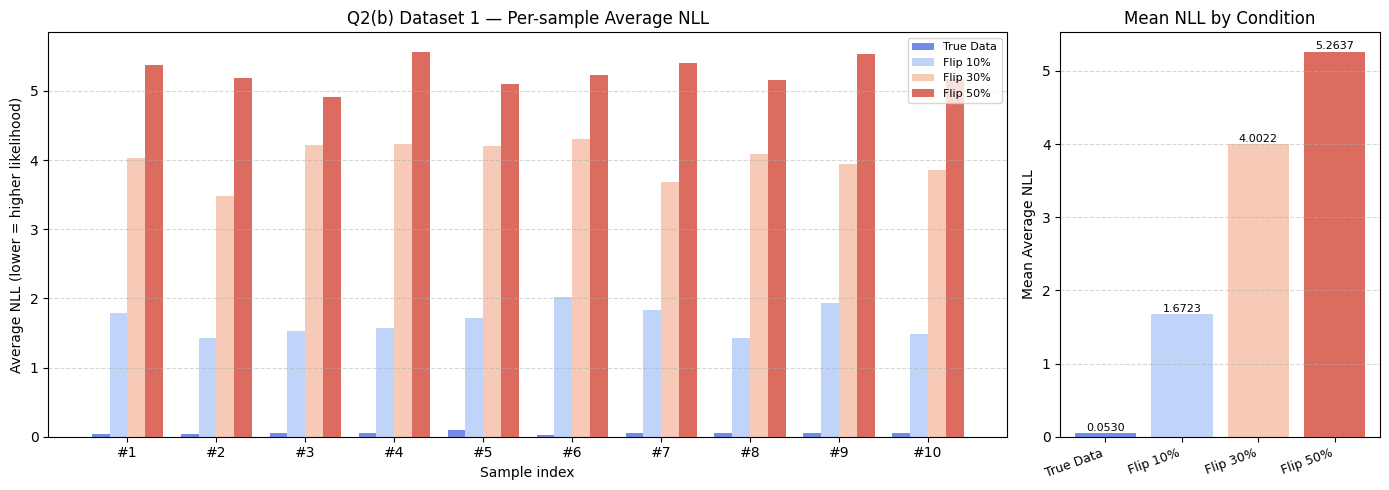

Saved: results/q2_b_dset1_nll_comparison.png


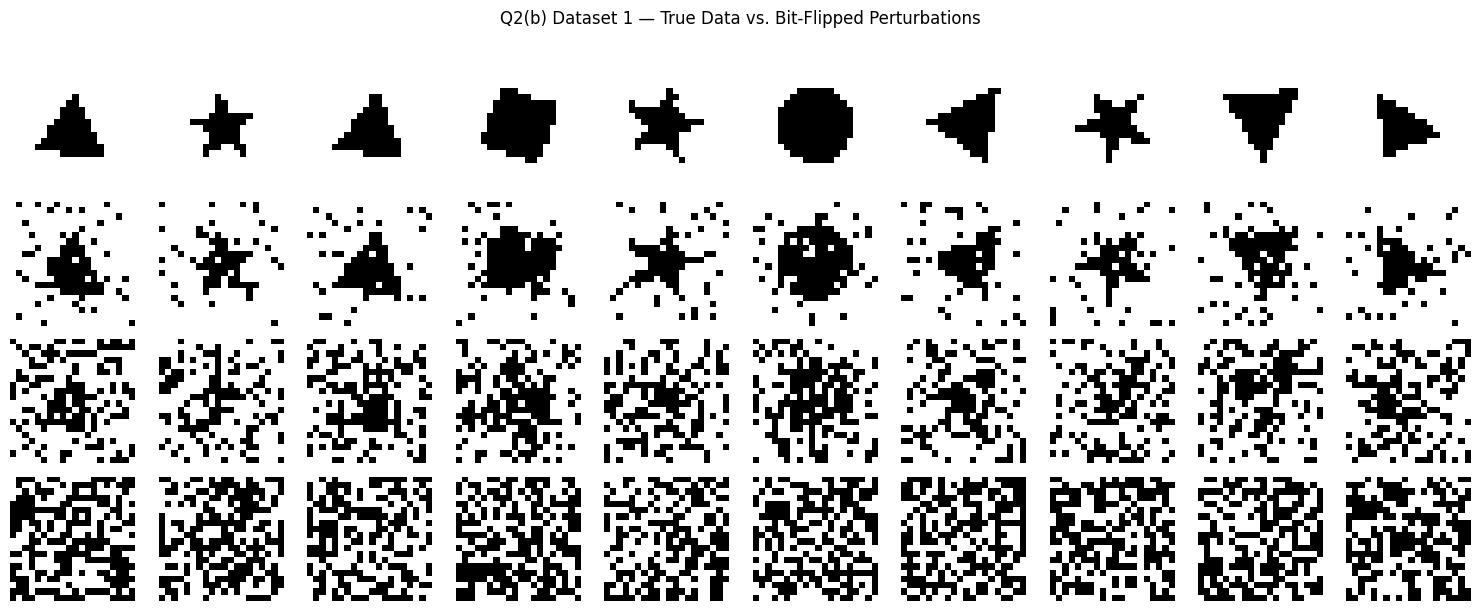

Saved: results/q2_b_dset1_samples.png


In [12]:
q2b_save_results(1, model_shape, q2_b)

  Average NLL Comparison

  Sample |    True Data |     Flip 10% |     Flip 30% |     Flip 50%
---------------------------------------------------------------------
  #   1   |       0.0550 |       0.6295 |       1.2076 |       1.3697
  #   2   |       0.0721 |       0.7891 |       1.2421 |       1.3968
  #   3   |       0.0300 |       0.7782 |       1.2533 |       1.3491
  #   4   |       0.0825 |       0.9242 |       1.2081 |       1.3790
  #   5   |       0.0850 |       0.8828 |       1.1634 |       1.3498
  #   6   |       0.0331 |       0.7161 |       1.2169 |       1.3802
  #   7   |       0.0836 |       0.8886 |       1.2639 |       1.4073
  #   8   |       0.0735 |       0.7564 |       1.2516 |       1.3582
  #   9   |       0.0992 |       0.7018 |       1.2357 |       1.4186
  #  10   |       0.0922 |       0.7931 |       1.3059 |       1.4159

    Mean  |       0.0706 |       0.7860 |       1.2348 |       1.3825



/app/workspace/KU_homework/generative_artificial_intelligence/assignment_2/hw1_helper.py:200: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)


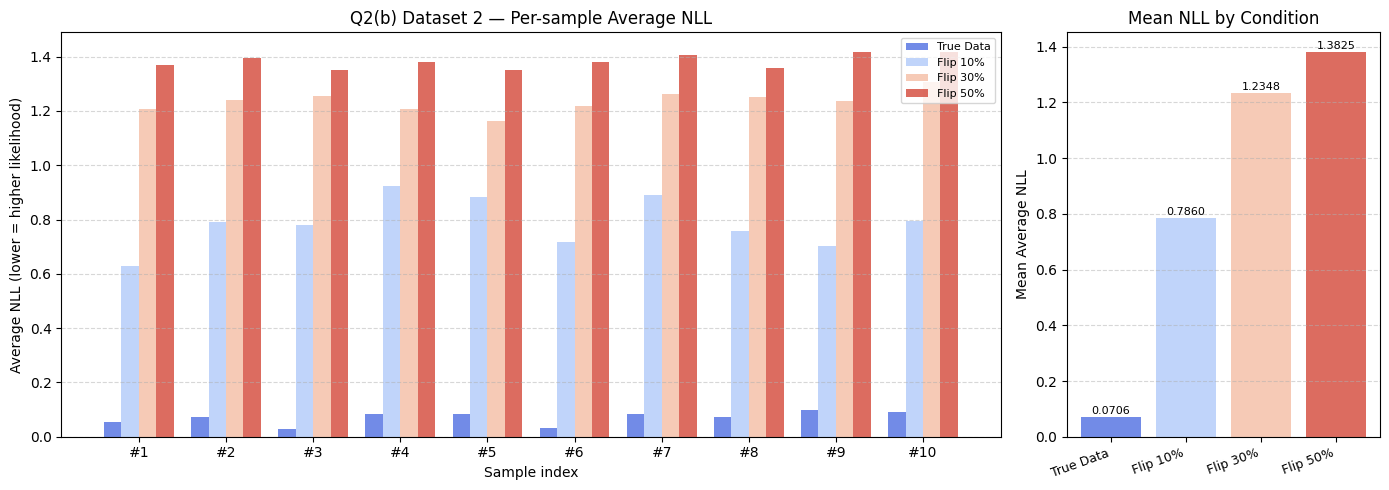

Saved: results/q2_b_dset2_nll_comparison.png


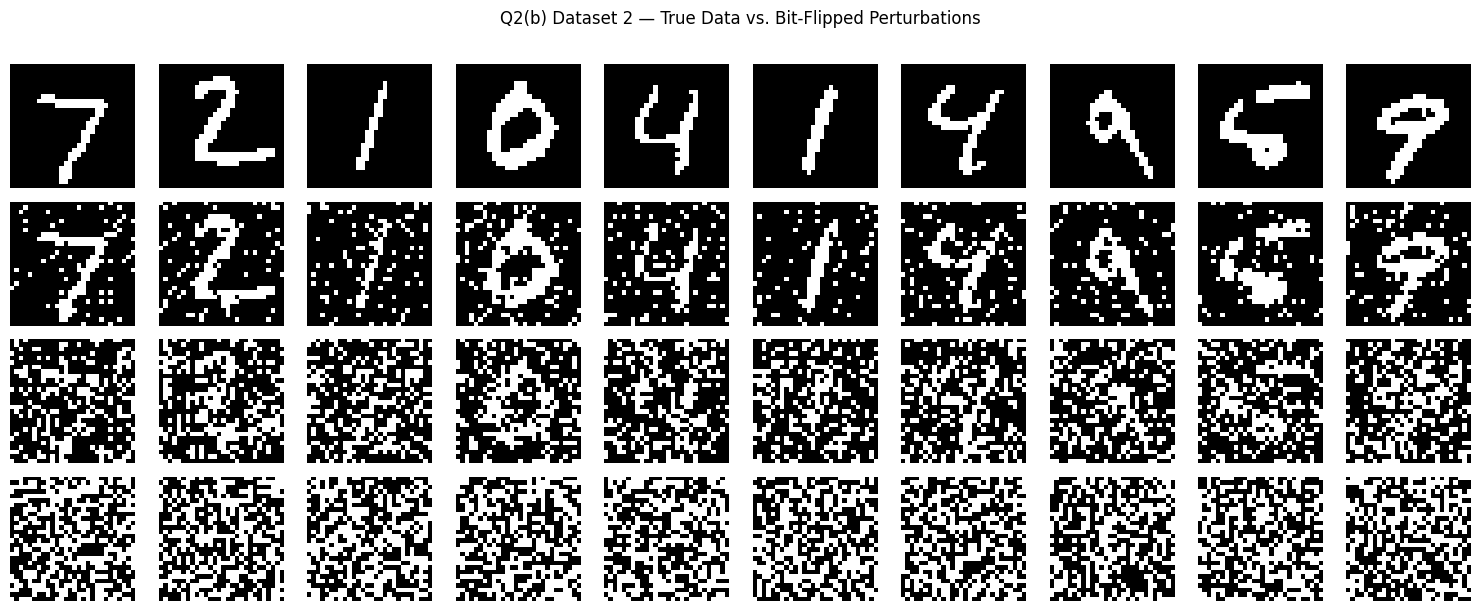

Saved: results/q2_b_dset2_samples.png


In [13]:
q2b_save_results(2, model_mnist, q2_b)